## Section 1 - Tổng quan dữ liệu (Data Overview)

Bộ dữ liệu bao gồm dữ liệu hoạt động của người dùng từ một trò chơi, bao gồm các sự kiện, giao dịch mua hàng, tiến trình chơi game và chi phí marketing.


## Section 2 - Tải dữ liệu (Load Dataset)



In [2]:
import pandas as pd

In [3]:
overview = pd.read_csv("overview_data.csv")
purchase = pd.read_csv("in_app_purchase.csv")
level = pd.read_csv("level_end.csv")
cost = pd.read_csv("cost.csv")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22708\843366020.py:1: DtypeWarning: Columns (0: product_id_iap, 1: placement, 2: ad_source, 3: ad_format) have mixed types. Specify dtype option on import or set low_memory=False.
  overview = pd.read_csv("overview_data.csv")


## Section 3 - Thống kê cơ bản (Basic Statistics)

Trước khi đi sâu vào phân tích, chúng ta cần xem qua các thông tin cơ bản của dataset bao gồm kích thước bảng dữ liệu và số lượng người dùng duy nhất.

Mục tiêu của bước này là hiểu được quy mô dữ liệu cũng như phạm vi phân tích.

In [4]:
overview.shape

(328507, 20)

In [65]:
purchase.shape

(237, 18)

In [66]:
level.shape

(1772341, 19)

In [67]:
cost.shape

(27, 2)

In [3]:
#Unique users:

overview["user_pseudo_id"].nunique()

74281

### Insight:

Dataset ghi nhận dữ liệu hoạt động của khoảng **74.000 người chơi khác nhau**.
Điều này cho thấy bộ dữ liệu có quy mô tương đối lớn và đủ để thực hiện
các phân tích hành vi người dùng và hiệu quả monetization của game.

## Section 4 - Phân bố sự kiện (Event Distribution)

Bước tiếp theo là phân tích các loại sự kiện xuất hiện trong dữ liệu.
Mỗi sự kiện đại diện cho một hành động mà người chơi thực hiện trong game, ví dụ như xem quảng cáo, hoàn thành level hoặc thực hiện mua hàng trong game.

Phân tích này giúp hiểu được người chơi tương tác với game theo cách nào và hoạt động nào diễn ra thường xuyên nhất.

In [4]:
overview["event_name"].value_counts()

event_name
ad_impression      164234
Level_End          124526
tutorial            39605
in_app_purchase       142
Name: count, dtype: int64

### Insight

Kết quả cho thấy **sự kiện hiển thị quảng cáo (ad impression)** chiếm tỷ trọng lớn nhất trong tổng số sự kiện.

Điều này cho thấy quảng cáo đóng vai trò quan trọng trong hoạt động của game và có khả năng là nguồn doanh thu chính.

Ngoài ra, các sự kiện liên quan đến gameplay như hoàn thành level cũng xuất hiện với tần suất cao, cho thấy người chơi có mức độ tương tác khá tốt với nội dung game.

## Section 5 — Tổng quan Monetization (Monetization Overview)

Một trong những mục tiêu quan trọng của phân tích game là đánh giá hiệu quả monetization (khả năng tạo doanh thu).

Trong phần này, chúng ta sẽ tính toán một số chỉ số quan trọng như:

- Tổng doanh thu
- Số lượng người chơi thực hiện mua hàng
- Tỷ lệ người chơi mua hàng (Buyer Rate)
- Doanh thu trung bình trên mỗi người chơi (ARPU)

In [5]:
#Total Revenue

overview["total_revenue"] = overview["rev_iap"] + overview["rev_iaa"]

overview["total_revenue"].sum()

np.float64(1902.2202704711965)

In [6]:
#Buyer

buyers = overview[overview["rev_iap"] > 0]["user_pseudo_id"].nunique()

buyers

69

In [7]:
#Buyer Rate
users = overview["user_pseudo_id"].nunique()

buyer_rate = buyers / users *100

buyer_rate

0.09289051035931127

In [8]:
#ARPU 

revenue = overview["total_revenue"].sum()

arpu = revenue / users

arpu

np.float64(0.023871422874967605)

### Insight

Dataset cho thấy trò chơi này có lượng người dùng tương đối lớn với khoảng **74.000** người chơi duy nhất.

Tuy nhiên, chỉ có **khoảng 69 người dùng** thực hiện mua hàng trong ứng dụng, dẫn đến tỷ lệ chuyển đổi mua hàng chỉ **khoảng 0,09%**. Con số này thấp hơn đáng kể so với mức chuẩn thông thường của các trò chơi di động là 2-5%.

Điều này cho thấy chiến lược kiếm tiền của trò chơi có thể dựa nhiều hơn vào doanh thu quảng cáo hơn là mua hàng trong ứng dụng, điều này được chứng minh bằng số lượng lớn các sự kiện hiển thị quảng cáo trong bộ dữ liệu.

## Section 6 - Phân tích người dùng hoạt động hằng ngày (DAU Analysis)

DAU (Daily Active User) là một trong những chỉ số quan trọng nhất trong phân tích game, thể hiện số lượng người chơi hoạt động mỗi ngày.

Chỉ số này giúp đánh giá mức độ duy trì người chơi và mức độ phổ biến của game theo thời gian.

In [9]:
dau = overview.groupby("event_date")["user_pseudo_id"].nunique()

dau.head()

event_date
7/15/2025    6901
7/16/2025    6647
7/17/2025    6348
7/18/2025    5068
7/19/2025    5522
Name: user_pseudo_id, dtype: int64

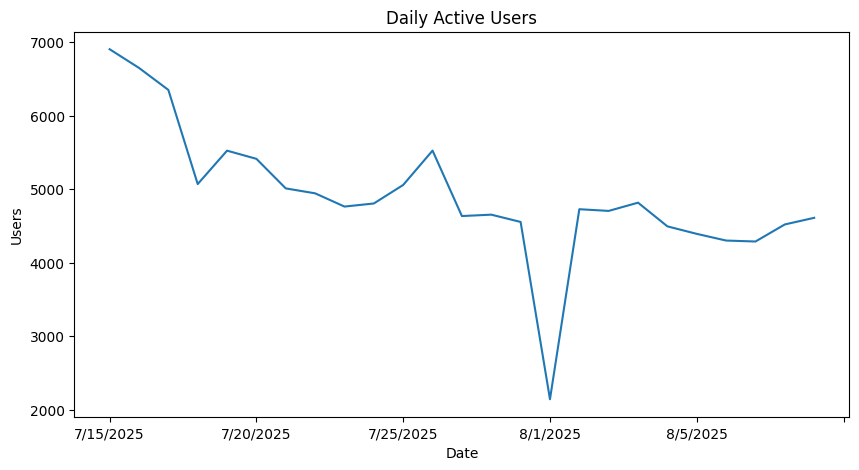

In [10]:
import matplotlib.pyplot as plt

dau.plot(figsize=(10,5))
plt.title("Daily Active Users")
plt.xlabel("Date")
plt.ylabel("Users")
plt.show()

### Insight

Số lượng người chơi hoạt động mỗi ngày (DAU) dao động trong khoảng **5.000 – 7.000 người chơi mỗi ngày**.

Xu hướng này cho thấy lượng người chơi tương đối ổn định trong khoảng thời gian quan sát, cho thấy game duy trì được một lượng người dùng hoạt động khá ổn định.

## Section 7 - Cơ cấu doanh thu (Revenue Breakdown)

Doanh thu trong game thường đến từ hai nguồn chính:

- In-app purchase (IAP): người chơi mua vật phẩm trong game
- In-app advertising (IAA): doanh thu từ quảng cáo

Việc phân tích cơ cấu doanh thu giúp hiểu rõ mô hình monetization mà game đang sử dụng.

In [6]:
revenue_breakdown = overview[["rev_iap", "rev_iaa"]].sum()

revenue_breakdown

rev_iap    947.741866
rev_iaa    954.478404
dtype: float64

In [7]:
revenue_percentage = revenue_breakdown / revenue_breakdown.sum() * 100

revenue_percentage

rev_iap    49.82293
rev_iaa    50.17707
dtype: float64

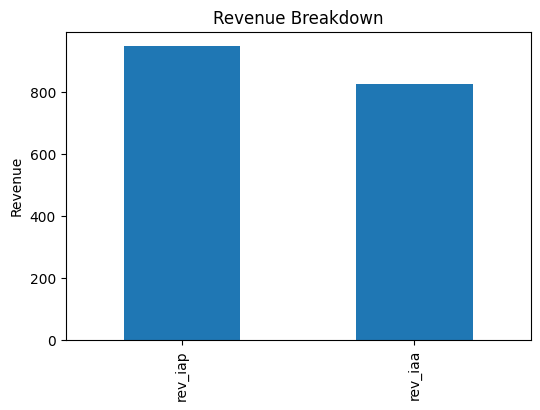

In [13]:
revenue_breakdown.plot(kind="bar", figsize=(6,4))

plt.title("Revenue Breakdown")
plt.ylabel("Revenue")
plt.show()

### Nhận xét

Kết quả phân tích cho thấy doanh thu từ quảng cáo (IAA) và doanh thu từ mua vật phẩm trong game (IAP) gần như tương đương nhau.

Cụ thể:
- IAP chiếm khoảng **50.2%** tổng doanh thu
- Quảng cáo chiếm khoảng **49.8%**

Điều này cho thấy game đang sử dụng mô hình monetization kết hợp, trong đó cả quảng cáo và in-app purchase đều đóng vai trò quan trọng trong việc tạo doanh thu.

## Section 8 - Phân tích theo quốc gia (Country Analysis)

Phân tích theo quốc gia giúp xác định thị trường nào mang lại nhiều người chơi và doanh thu nhất.

Điều này rất quan trọng đối với các studio game vì nó giúp xác định các thị trường trọng điểm để tập trung marketing hoặc tối ưu monetization.

In [81]:
users_by_country = overview.groupby("country")["user_pseudo_id"].nunique().sort_values(ascending=False)

users_by_country.head(10)

country
India            11990
Iran              6545
Indonesia         4386
Egypt             4348
Pakistan          4143
Algeria           3584
Bangladesh        3308
Iraq              2365
United States     1975
Nigeria           1765
Name: user_pseudo_id, dtype: int64

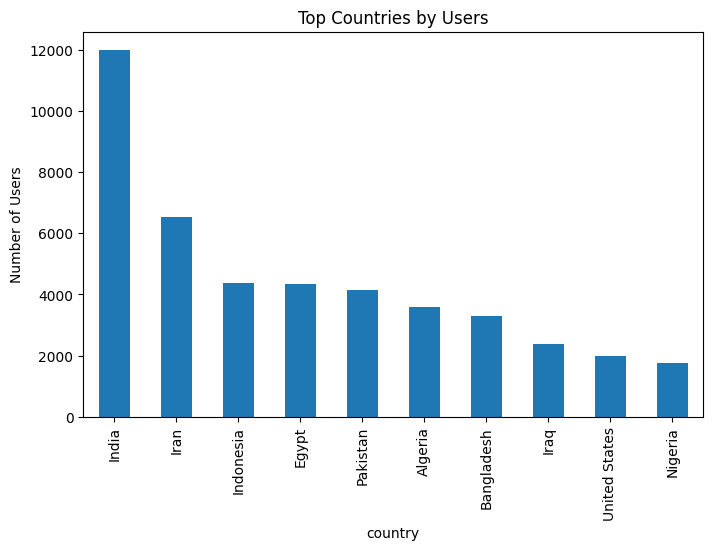

In [79]:
users_by_country.head(10).plot(kind="bar", figsize=(8,5))

plt.title("Top Countries by Users")
plt.ylabel("Number of Users")
plt.show()

In [82]:
revenue_by_country = overview.groupby("country")["total_revenue"].sum().sort_values(ascending=False)

revenue_by_country.head(10)

country
United States     567.143050
Japan             175.531853
United Kingdom    165.855729
South Korea       110.345000
Brazil             83.563599
Denmark            75.185060
Germany            73.091609
Canada             57.414894
Slovakia           51.809921
France             44.293386
Name: total_revenue, dtype: float64

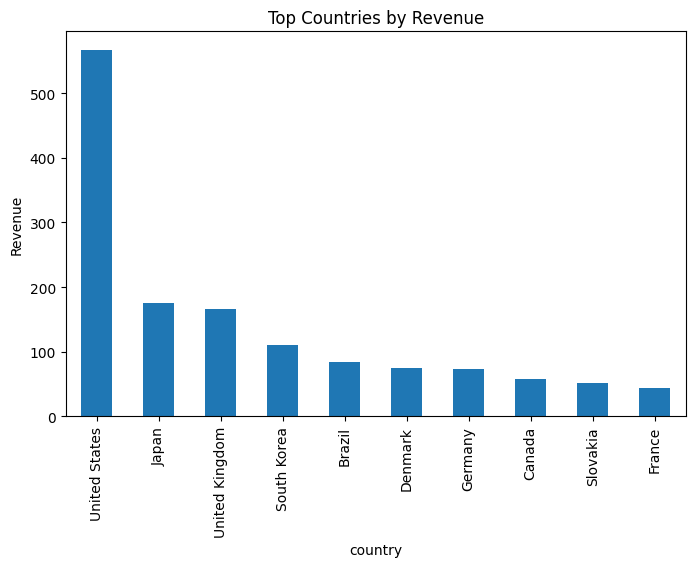

In [83]:
revenue_by_country.head(10).plot(kind="bar", figsize=(8,5))

plt.title("Top Countries by Revenue")
plt.ylabel("Revenue")
plt.show()

### Insight

Phân tích theo quốc gia cho thấy sự khác biệt rõ rệt giữa thị trường có nhiều người chơi và thị trường tạo ra nhiều doanh thu.

Các quốc gia như **India, Iran và Indonesia** có số lượng người chơi cao nhất, cho thấy game có độ phổ biến lớn tại các thị trường đang phát triển.

Tuy nhiên, khi xét về doanh thu, **United States, Japan và United Kingdom** lại là những quốc gia đóng góp nhiều doanh thu nhất mặc dù số lượng người chơi không nằm trong nhóm cao nhất.

Điều này cho thấy hành vi chi tiêu giữa các thị trường có sự khác biệt đáng kể. Các quốc gia phát triển thường có **ARPU cao hơn**, trong khi các thị trường đông người chơi lại chủ yếu đóng góp vào lượng người dùng hơn là doanh thu.

Insight này gợi ý rằng studio game có thể áp dụng các chiến lược khác nhau cho từng thị trường:

* Tập trung **user acquisition** tại các thị trường đông người chơi.
* Tối ưu **monetization** tại các thị trường có khả năng chi tiêu cao.


## Section 9 - Phân tích giữ chân (Retention Analysis)

Retention đo lường khả năng game giữ chân người chơi quay lại sau ngày đầu tiên họ cài đặt game.

Đây là một trong những chỉ số quan trọng nhất trong phân tích game vì nó phản ánh mức độ hấp dẫn của gameplay.

In [ ]:
## First day của user

first_play = overview.groupby("user_pseudo_id")["event_date"].min().reset_index()

first_play.columns = ["user_pseudo_id","first_day"]

In [ ]:
retention = overview.merge(first_play, on="user_pseudo_id")

In [ ]:
retention["days_since_install"] = (
    pd.to_datetime(retention["event_date"]) -
    pd.to_datetime(retention["first_day"])
).dt.days

In [ ]:
retention_table = retention.groupby("days_since_install")["user_pseudo_id"].nunique()

retention_table.head(10)

days_since_install
0    74281
1    10334
2     5913
3     4425
4     3552
5     2991
6     2536
7     2280
8     1922
9     1653
Name: user_pseudo_id, dtype: int64

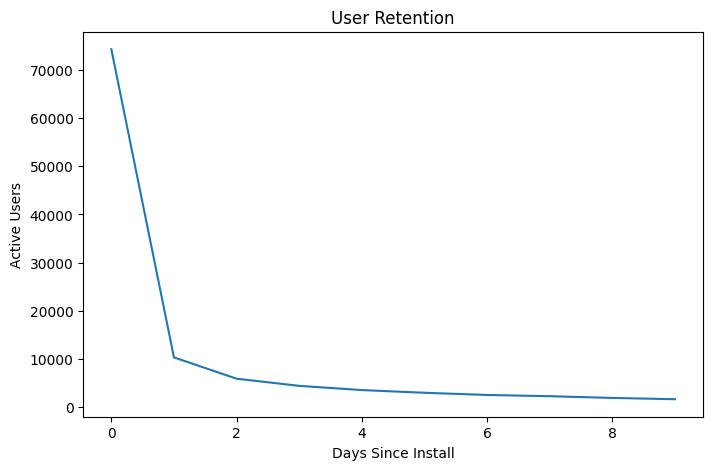

In [ ]:
retention_table.head(10).plot(figsize=(8,5))

plt.title("User Retention")
plt.xlabel("Days Since Install")
plt.ylabel("Active Users")
plt.show()

### Insight

Kết quả phân tích cho thấy số lượng người chơi hoạt động giảm mạnh sau ngày đầu tiên cài đặt game.

Cụ thể, từ khoảng **74,000 người chơi trong ngày đầu**, số lượng người quay lại vào ngày thứ hai giảm xuống còn khoảng **10,000**, tương đương tỷ lệ giữ chân khoảng **14%**.

Sau đó, số lượng người chơi tiếp tục giảm dần theo thời gian, cho thấy một phần lớn người chơi rời bỏ game trong những ngày đầu trải nghiệm.

Đây là hiện tượng phổ biến trong các game mobile, tuy nhiên mức giảm mạnh ngay sau ngày đầu có thể cho thấy trải nghiệm onboarding hoặc độ hấp dẫn của gameplay ở giai đoạn đầu chưa đủ mạnh để giữ chân người chơi.

Studio game có thể cải thiện retention bằng cách:

* Tối ưu **onboarding experience** cho người chơi mới
* Điều chỉnh **độ khó các level đầu**
* Thêm **reward hoặc progression system** trong những ngày đầu.


## **Overall Insight**


Phân tích dữ liệu cho thấy game đang sử dụng mô hình monetization kết hợp giữa quảng cáo và mua vật phẩm trong game.

Mặc dù tỷ lệ người chơi thực hiện mua hàng khá thấp, doanh thu từ IAP vẫn chiếm gần một nửa tổng doanh thu, cho thấy có thể tồn tại một nhóm nhỏ người chơi chi tiêu nhiều.

Bên cạnh đó, dữ liệu retention cho thấy số lượng người chơi giảm mạnh sau ngày đầu tiên, điều này cho thấy cơ hội cải thiện trải nghiệm giai đoạn đầu của game để tăng khả năng giữ chân người chơi.

Việc cải thiện retention có thể giúp gia tăng đáng kể doanh thu trong dài hạn vì nhiều người chơi ở lại game hơn sẽ đồng nghĩa với nhiều cơ hội hiển thị quảng cáo và thực hiện mua hàng trong game.


In [4]:
overview.to_csv("clean_game_data.csv", index=False)